# Timbre synthesis

*Copyright Peter Harrison (pmch2@cam.ac.uk), University of Cambridge, 2024*

This notebook provides a simple interface for generating sounds using additive synthesis.


In [1]:
# @title
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import IPython
import librosa
import librosa.display
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import soundfile as sf

from IPython.display import set_matplotlib_formats
from statistics import mean

sns.set_style("white")

plt.rcParams['figure.dpi'] = 125
plt.rcParams['figure.figsize'] = (10, 5)


matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


def show_sound(samples, sample_rate, filename):
    plot_waveform(samples, sample_rate)
    plot_spectrogram(samples, sample_rate)
    return play_samples(samples, sample_rate, filename)


def plot_waveform(samples, sample_rate, num_seconds_to_plot=0.05):
    num_samples_to_plot = round(num_seconds_to_plot * sample_rate)

    librosa.display.waveshow(
        samples[:num_samples_to_plot],
        sr=sample_rate,
    )
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

    # ax.set(
    #     xlabel="Time (seconds)",
    #     ylabel="Amplitude"
    # )


def plot_spectrogram(samples, sample_rate):
    N_FFT = 2048  # This should be a power of 2 for optimal FFT efficiency

    D = librosa.stft(samples)
    spectrogram = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    spec_frequencies = librosa.fft_frequencies(sr=sample_rate, n_fft=N_FFT)
    spec_times = [i / sample_rate for i in range(len(samples))]

    fig, ax = plt.subplots()
    img = librosa.display.specshow(spectrogram, x_axis='time', y_axis='linear', ax=ax, sr=sample_rate)
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    fig.show()


def play_samples(samples, sample_rate, filename):
    sf.write(filename, samples, sample_rate)
    return IPython.display.Audio(filename, autoplay=True)

def mix_waves(*args):
    mixed = np.sum([*args], axis=0)
    normed = mixed / mixed.max()
    return normed

def pure_tone(
        frequency,  # Hz
        sample_rate,
        duration=2.0,  # seconds
        amplitude=1.0,
    ):
  n_samples = int(duration * sample_rate)

  # np.arange creates a vector of the form [0, 1, 2, ..., n_samples]
  # Divide this by sample_rate and we get a vector of times (in seconds)
  # We can then put this into the wave formula: y = A sin(2 * pi * f * t )
  return amplitude * np.sin(2 * np.pi * frequency * np.arange(n_samples) / sample_rate)

sample_rate = 44100 # samples per second

def adsr(
    wave,
    attack,
    decay,
    sustain,
    release,
    duration,  # does not include the release period
    sample_rate,
):
    hold = duration - attack - decay

    x_anchors = [
        0,
        attack,
        attack + decay,
        attack + decay + hold,
        attack + decay + hold + release,
    ]
    y_anchors = [
        0,
        1,
        sustain,
        sustain,
        0,
    ]

    n_samples = len(wave)
    sample_times = np.arange(n_samples) / sample_rate

    envelope = np.interp(
        sample_times,
        x_anchors,
        y_anchors,
    )

    return wave * envelope

import numpy as np
import seaborn as sns

def get_spectrogram(
      audio,
      sample_rate,
      n_fft=2048  # this should be a power of 2 for efficient computation
    ):
    n_samples = len(audio)
    D = librosa.stft(audio)
    return {
        "values": librosa.amplitude_to_db(np.abs(D), ref=np.max),
        "frequencies": librosa.fft_frequencies(sr=sample_rate),
        "times": np.arange(n_samples) / sample_rate,
    }

def get_spectrum(
        audio,
        sample_rate,
        n_fft=2048  # this should be a power of 2 for efficient computation
    ):
    spectrogram = get_spectrogram(audio, sample_rate, n_fft)
    spectrum_values = np.mean(spectrogram["values"], axis=1)
    spectrum_frequencies = spectrogram["frequencies"]
    ax = sns.lineplot(
        x=spectrum_frequencies,
        y=spectrum_values,
    )
    ax.set(
        xlabel="Frequency (Hz)",
        ylabel="Level (dB)",
    )
    ax.set_xlim(0, 10000)
    return {
        "frequencies": spectrum_frequencies,
        "values": spectrum_values,
        "ax": ax,
    }

This program generates harmonic sounds by creating a number of sinusoids, each harmonically related to a fundamental frequency, and each with customisable amplitudes. The envelope of the sound is then customised using the ADSR model.

The ADSR envelope has four discrete sections: attack, decay, sustain, and release.

![ADSR image](https://drive.google.com/uc?id=1bBqE8tFsbTB8jpCHtkhL2-JAxfc0z7eW)

We customise ADSR envelope using four parameters:

- Attack: the duration of the attack segment
- Decay: the duration of the decay segment
- Sustain: the amplitude of the sustain segment
- Release: the duration of the release segment

To use the synthesiser, press Runtime > Run all,
then move your mouse just to the left of 'f0' (or '# @title', if you
have the code window open)
and click the Play button that appears.
Now you can update the synthesiser's parameters by
moving sliders and entering numbers, and a new sound should be
generated and played automatically.

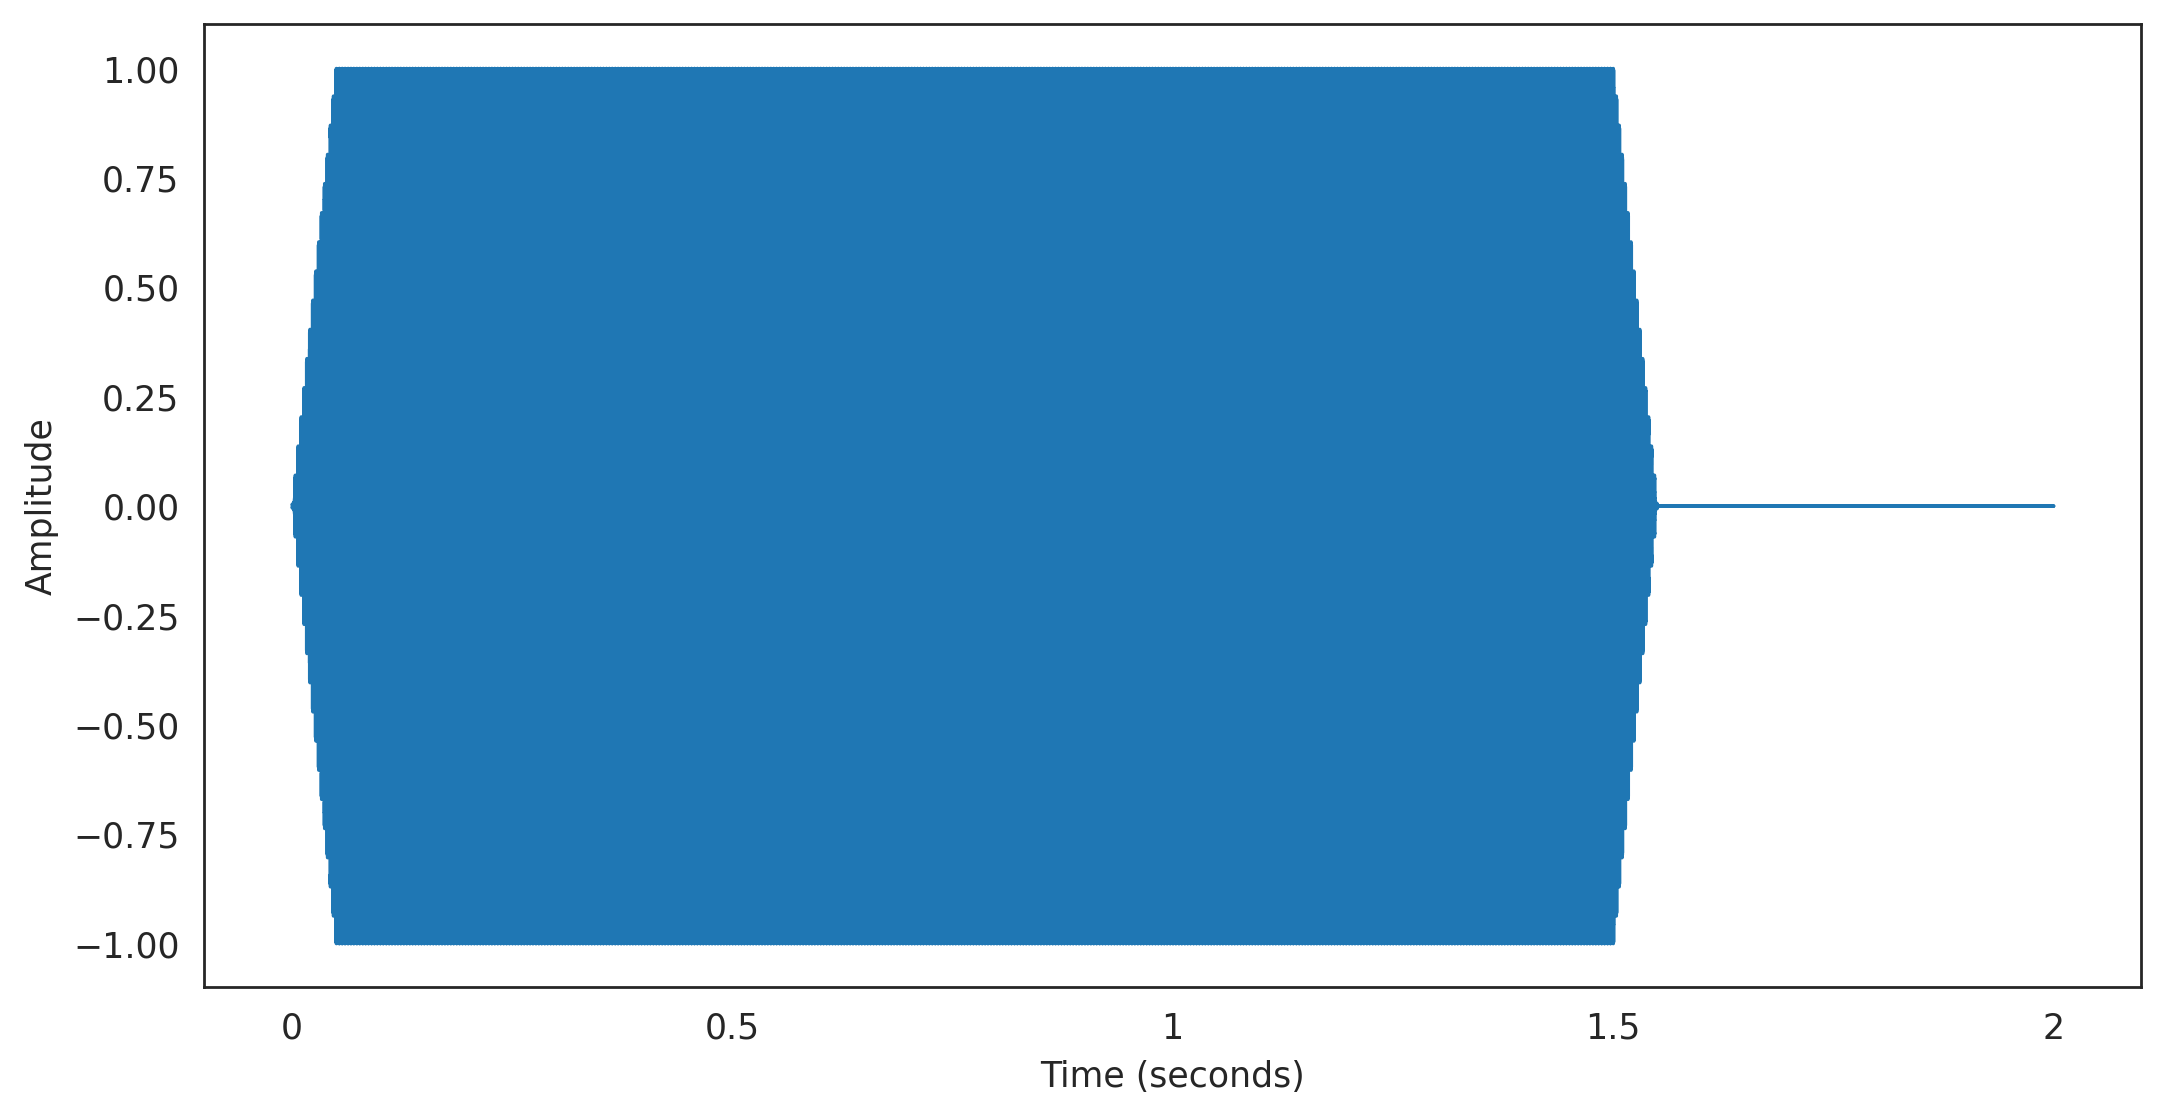

Button(description='Download parameters', style=ButtonStyle())

In [9]:
# @title { run: "auto" }

import ipywidgets as widgets

from google.colab import files
from IPython.display import display


f0 = 300 # @param {type:"number"}

amplitude_0 = 0.467 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_1 = 0.324 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_2 = 0.416 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_3 = 0.26 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_4 = 0.193 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_5 = 0.175 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_6 = 0.146 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_7 = 0.01 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_8 = 0.01 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_9 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_10 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_11 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_12 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_13 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_14 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_15 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_16 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_17 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_18 = 0 # @param {type: "slider", min:0, max:1, step:0.001}
amplitude_19 = 0 # @param {type: "slider", min:0, max:1, step:0.001}

attack = 0.05 # @param {type: "number"}
decay = 0.0 # @param {type: "number"}
sustain = 1 # @param {type: "number"}
release = 0.05 # @param {type: "number"}
duration = 1.5 # @param {type: "number"}

n_harmonics = 20
frequencies = [f0 * (i + 1) for i in range(n_harmonics)]
amplitudes = [globals()[f"amplitude_{i}"] for i in range(n_harmonics)]

tone = mix_waves(*[
    pure_tone(frequency=f, amplitude=a, sample_rate=sample_rate)
    for f, a in zip(frequencies, amplitudes)
])

tone = adsr(
    tone,
    attack=attack,
    decay=decay,
    sustain=sustain,
    release=release,
    duration=duration,
    sample_rate=sample_rate,
)

# noise_amplitude = 0.1 # @param {type: "number"}
# noise_attack = 0.0 # @param {type: "number"}
# noise_decay = 0.0 # @param {type: "number"}
# noise_sustain = 1 # @param {type: "number"}
# noise_release = 0.5 # @param {type: "number"}

# noise = np.random.randn(sample_rate * duration) * noise_amplitude

# noise = adsr(
#     noise,
#     attack=noise_attack,
#     decay=noise_decay,
#     sustain=noise_sustain,
#     release=noise_release,
#     duration=0.00001,
#     sample_rate=sample_rate,
# )

# mixed = mix_waves(tone, noise * 0.1)

# spectrum = get_spectrum(tone, sample_rate)
# plt.show()

def download_params(b):
    df = {
        "f0": f0,
        "attack": attack,
        "decay": decay,
        "sustain": sustain,
        "release": release,
    }

    for i, amplitude in enumerate(amplitudes):
        df[f"amplitude_{i}"] = amplitude

    df = pd.DataFrame.from_records([df])
    df.to_csv("params.csv", index=False)
    files.download("params.csv")

button_params = widgets.Button(description="Download parameters")
button_params.on_click(download_params)

plot_waveform(tone, sample_rate, num_seconds_to_plot=2)
plt.show()

display(button_params)
play_samples(tone, sample_rate, filename="tone.wav")